In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import duckdb

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

top200_path = PROCESSED_DIR / "charts_top200_clean.parquet"
viral50_path = PROCESSED_DIR / "charts_viral50_clean.parquet"

top200_path, viral50_path

(PosixPath('../data/processed/charts_top200_clean.parquet'),
 PosixPath('../data/processed/charts_viral50_clean.parquet'))

In [2]:
con = duckdb.connect()

In [3]:
con.execute(f"""
SELECT *
FROM read_parquet('{top200_path}')
LIMIT 5
""").df()

,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,223988.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,210943.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,173865.0
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0


In [4]:
daily_top200_region = con.execute(f"""
SELECT
    region,
    date,
    SUM(streams) AS total_streams,
    AVG(streams) AS avg_streams_per_track,
    COUNT(*) AS chart_entries,
    COUNT(DISTINCT title || ' - ' || artist) AS unique_tracks,
    COUNT(DISTINCT artist) AS unique_artists,
    AVG(rank) AS avg_rank,
    MIN(rank) AS best_rank,
    SUM(CASE WHEN trend = 'MOVE_UP' THEN 1 ELSE 0 END) AS move_up_count,
    SUM(CASE WHEN trend = 'MOVE_DOWN' THEN 1 ELSE 0 END) AS move_down_count,
    SUM(CASE WHEN trend = 'NEW_ENTRY' THEN 1 ELSE 0 END) AS new_entry_count,
    SUM(CASE WHEN trend = 'SAME_POSITION' THEN 1 ELSE 0 END) AS same_position_count
FROM read_parquet('{top200_path}')
GROUP BY region, date
ORDER BY region, date
""").df()

daily_top200_region.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,region,date,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,move_down_count,new_entry_count,same_position_count
0,Argentina,2017-01-01,7888872.0,39444.360,200,200,131,100.5,1,65.0,94.0,26.0,15.0
1,Argentina,2017-01-02,6010041.0,30050.205,200,200,135,100.5,1,89.0,59.0,46.0,6.0
2,Argentina,2017-01-03,5921907.0,29609.535,200,200,135,100.5,1,87.0,92.0,5.0,16.0
3,Argentina,2017-01-04,6019573.0,30097.865,200,200,140,100.5,1,77.0,95.0,12.0,16.0
4,Argentina,2017-01-05,6223646.0,31118.230,200,200,140,100.5,1,83.0,86.0,6.0,25.0


In [6]:
daily_top200_region["move_up_share"] = (
    daily_top200_region["move_up_count"] / daily_top200_region["chart_entries"]
)

daily_top200_region["move_down_share"] = (
    daily_top200_region["move_down_count"] / daily_top200_region["chart_entries"]
)

daily_top200_region["new_entry_share"] = (
    daily_top200_region["new_entry_count"] / daily_top200_region["chart_entries"]
)

daily_top200_region["same_position_share"] = (
    daily_top200_region["same_position_count"] / daily_top200_region["chart_entries"]
)

daily_top200_region.head()

,region,date,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,move_down_count,new_entry_count,same_position_count,move_up_share,move_down_share,new_entry_share,same_position_share
0,Argentina,2017-01-01,7888872.0,39444.360,200,200,131,100.5,1,65.0,94.0,26.0,15.0,0.325,0.470,0.130,0.075
1,Argentina,2017-01-02,6010041.0,30050.205,200,200,135,100.5,1,89.0,59.0,46.0,6.0,0.445,0.295,0.230,0.030
2,Argentina,2017-01-03,5921907.0,29609.535,200,200,135,100.5,1,87.0,92.0,5.0,16.0,0.435,0.460,0.025,0.080
3,Argentina,2017-01-04,6019573.0,30097.865,200,200,140,100.5,1,77.0,95.0,12.0,16.0,0.385,0.475,0.060,0.080
4,Argentina,2017-01-05,6223646.0,31118.230,200,200,140,100.5,1,83.0,86.0,6.0,25.0,0.415,0.430,0.030,0.125


In [7]:
daily_top200_region["date"] = pd.to_datetime(daily_top200_region["date"])

daily_top200_region["week"] = (
    daily_top200_region["date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

weekly_top200_region = (
    daily_top200_region
    .groupby(["region", "week"], as_index=False)
    .agg({
        "total_streams": "sum",
        "avg_streams_per_track": "mean",
        "chart_entries": "sum",
        "unique_tracks": "sum",
        "unique_artists": "sum",
        "avg_rank": "mean",
        "best_rank": "min",
        "move_up_count": "sum",
        "move_down_count": "sum",
        "new_entry_count": "sum",
        "same_position_count": "sum",
        "move_up_share": "mean",
        "move_down_share": "mean",
        "new_entry_share": "mean",
        "same_position_share": "mean"
    })
)

weekly_top200_region.head()

,region,week,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,move_down_count,new_entry_count,same_position_count,move_up_share,move_down_share,new_entry_share,same_position_share
0,Argentina,2016-12-26,7888872.0,39444.360000,200,200,131,100.5,1,65.0,94.0,26.0,15.0,0.325000,0.470000,0.130000,0.075000
1,Argentina,2017-01-02,43192339.0,30851.670714,1400,1400,967,100.5,1,556.0,612.0,98.0,134.0,0.397143,0.437143,0.070000,0.095714
2,Argentina,2017-01-09,43603549.0,31145.392143,1400,1400,974,100.5,1,544.0,597.0,58.0,201.0,0.388571,0.426429,0.041429,0.143571
3,Argentina,2017-01-16,45643782.0,32602.701429,1400,1400,971,100.5,1,532.0,606.0,64.0,198.0,0.380000,0.432857,0.045714,0.141429
4,Argentina,2017-01-23,46698731.0,33356.236429,1400,1400,977,100.5,1,571.0,570.0,66.0,193.0,0.407857,0.407143,0.047143,0.137857


In [8]:
weekly_top200_region = weekly_top200_region.sort_values(["region", "week"])

weekly_top200_region["streams_lag_1_week"] = (
    weekly_top200_region
    .groupby("region")["total_streams"]
    .shift(1)
)

weekly_top200_region["weekly_stream_growth"] = (
    (weekly_top200_region["total_streams"] - weekly_top200_region["streams_lag_1_week"])
    / weekly_top200_region["streams_lag_1_week"]
)

weekly_top200_region["streams_rolling_4_week_avg"] = (
    weekly_top200_region
    .groupby("region")["total_streams"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
)

weekly_top200_region["streams_vs_4_week_avg"] = (
    (weekly_top200_region["total_streams"] - weekly_top200_region["streams_rolling_4_week_avg"])
    / weekly_top200_region["streams_rolling_4_week_avg"]
)

weekly_top200_region.head(10)

,region,week,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,...,new_entry_count,same_position_count,move_up_share,move_down_share,new_entry_share,same_position_share,streams_lag_1_week,weekly_stream_growth,streams_rolling_4_week_avg,streams_vs_4_week_avg
0,Argentina,2016-12-26,7888872.0,39444.360000,200,200,131,100.5,1,65.0,...,26.0,15.0,0.325000,0.470000,0.130000,0.075000,NaN,NaN,NaN,NaN
1,Argentina,2017-01-02,43192339.0,30851.670714,1400,1400,967,100.5,1,556.0,...,98.0,134.0,0.397143,0.437143,0.070000,0.095714,7888872.0,4.475097,7.888872e+06,4.475097
2,Argentina,2017-01-09,43603549.0,31145.392143,1400,1400,974,100.5,1,544.0,...,58.0,201.0,0.388571,0.426429,0.041429,0.143571,43192339.0,0.009520,2.554061e+07,0.707225
3,Argentina,2017-01-16,45643782.0,32602.701429,1400,1400,971,100.5,1,532.0,...,64.0,198.0,0.380000,0.432857,0.045714,0.141429,43603549.0,0.046791,3.156159e+07,0.446181
4,Argentina,2017-01-23,46698731.0,33356.236429,1400,1400,977,100.5,1,571.0,...,66.0,193.0,0.407857,0.407143,0.047143,0.137857,45643782.0,0.023113,3.508214e+07,0.331126
5,Argentina,2017-01-30,48097019.0,34355.013571,1400,1400,1009,100.5,1,545.0,...,68.0,222.0,0.389286,0.403571,0.048571,0.158571,46698731.0,0.029943,4.478460e+07,0.073963
6,Argentina,2017-02-06,48602348.0,34715.962857,1400,1400,1032,100.5,1,539.0,...,63.0,221.0,0.385000,0.412143,0.045000,0.157857,48097019.0,0.010506,4.601077e+07,0.056325
7,Argentina,2017-02-13,48879077.0,34913.626429,1400,1400,1043,100.5,1,532.0,...,65.0,228.0,0.380000,0.410714,0.046429,0.162857,48602348.0,0.005694,4.726047e+07,0.034249
8,Argentina,2017-02-20,48900075.0,34928.625000,1400,1400,1048,100.5,1,512.0,...,77.0,232.0,0.365714,0.413571,0.055000,0.165714,48879077.0,0.000430,4.806929e+07,0.017283
9,Argentina,2017-02-27,48386865.0,34562.046429,1400,1400,1029,100.5,1,523.0,...,69.0,201.0,0.373571,0.433571,0.049286,0.143571,48900075.0,-0.010495,4.861963e+07,-0.004787


In [9]:
daily_viral50_region = con.execute(f"""
SELECT
    region,
    date,
    COUNT(*) AS viral_entries,
    COUNT(DISTINCT title || ' - ' || artist) AS viral_unique_tracks,
    COUNT(DISTINCT artist) AS viral_unique_artists,
    AVG(rank) AS viral_avg_rank,
    MIN(rank) AS viral_best_rank,
    SUM(CASE WHEN trend = 'MOVE_UP' THEN 1 ELSE 0 END) AS viral_move_up_count,
    SUM(CASE WHEN trend = 'MOVE_DOWN' THEN 1 ELSE 0 END) AS viral_move_down_count,
    SUM(CASE WHEN trend = 'NEW_ENTRY' THEN 1 ELSE 0 END) AS viral_new_entry_count,
    SUM(CASE WHEN trend = 'SAME_POSITION' THEN 1 ELSE 0 END) AS viral_same_position_count
FROM read_parquet('{viral50_path}')
GROUP BY region, date
ORDER BY region, date
""").df()

daily_viral50_region.head()

,region,date,viral_entries,viral_unique_tracks,viral_unique_artists,viral_avg_rank,viral_best_rank,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count
0,Andorra,2017-01-01,25,25,23,13.0,1,13.0,5.0,2.0,5.0
1,Andorra,2017-01-02,25,25,22,13.0,1,11.0,8.0,3.0,3.0
2,Andorra,2017-01-03,25,25,22,13.0,1,8.0,4.0,1.0,12.0
3,Andorra,2017-01-04,22,22,20,11.5,1,14.0,1.0,3.0,4.0
4,Andorra,2017-01-05,16,16,15,8.5,1,9.0,1.0,5.0,1.0


In [10]:
daily_viral50_region["viral_move_up_share"] = (
    daily_viral50_region["viral_move_up_count"] / daily_viral50_region["viral_entries"]
)

daily_viral50_region["viral_move_down_share"] = (
    daily_viral50_region["viral_move_down_count"] / daily_viral50_region["viral_entries"]
)

daily_viral50_region["viral_new_entry_share"] = (
    daily_viral50_region["viral_new_entry_count"] / daily_viral50_region["viral_entries"]
)

daily_viral50_region["viral_same_position_share"] = (
    daily_viral50_region["viral_same_position_count"] / daily_viral50_region["viral_entries"]
)

daily_viral50_region.head()

,region,date,viral_entries,viral_unique_tracks,viral_unique_artists,viral_avg_rank,viral_best_rank,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share
0,Andorra,2017-01-01,25,25,23,13.0,1,13.0,5.0,2.0,5.0,0.520000,0.200000,0.080000,0.200000
1,Andorra,2017-01-02,25,25,22,13.0,1,11.0,8.0,3.0,3.0,0.440000,0.320000,0.120000,0.120000
2,Andorra,2017-01-03,25,25,22,13.0,1,8.0,4.0,1.0,12.0,0.320000,0.160000,0.040000,0.480000
3,Andorra,2017-01-04,22,22,20,11.5,1,14.0,1.0,3.0,4.0,0.636364,0.045455,0.136364,0.181818
4,Andorra,2017-01-05,16,16,15,8.5,1,9.0,1.0,5.0,1.0,0.562500,0.062500,0.312500,0.062500


In [11]:
daily_viral50_region["date"] = pd.to_datetime(daily_viral50_region["date"])

daily_viral50_region["week"] = (
    daily_viral50_region["date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

weekly_viral50_region = (
    daily_viral50_region
    .groupby(["region", "week"], as_index=False)
    .agg({
        "viral_entries": "sum",
        "viral_unique_tracks": "sum",
        "viral_unique_artists": "sum",
        "viral_avg_rank": "mean",
        "viral_best_rank": "min",
        "viral_move_up_count": "sum",
        "viral_move_down_count": "sum",
        "viral_new_entry_count": "sum",
        "viral_same_position_count": "sum",
        "viral_move_up_share": "mean",
        "viral_move_down_share": "mean",
        "viral_new_entry_share": "mean",
        "viral_same_position_share": "mean"
    })
)

weekly_viral50_region.head()

,region,week,viral_entries,viral_unique_tracks,viral_unique_artists,viral_avg_rank,viral_best_rank,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share
0,Andorra,2016-12-26,25,25,23,13.000000,1,13.0,5.0,2.0,5.0,0.520000,0.200000,0.080000,0.200000
1,Andorra,2017-01-02,130,130,119,9.785714,1,56.0,25.0,15.0,34.0,0.429184,0.192942,0.116232,0.261643
2,Andorra,2017-01-09,206,206,146,15.214286,1,53.0,88.0,40.0,25.0,0.247998,0.414452,0.211623,0.125927
3,Andorra,2017-01-16,147,147,128,11.000000,1,57.0,45.0,21.0,24.0,0.401296,0.272036,0.152895,0.173773
4,Andorra,2017-01-23,108,108,108,8.214286,1,30.0,35.0,16.0,27.0,0.286250,0.320008,0.148263,0.245479


In [12]:
weekly_regional_features = weekly_top200_region.merge(
    weekly_viral50_region,
    on=["region", "week"],
    how="left"
)

weekly_regional_features.head()

,region,week,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,...,viral_avg_rank,viral_best_rank,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share
0,Argentina,2016-12-26,7888872.0,39444.360000,200,200,131,100.5,1,65.0,...,25.5,1.0,22.0,13.0,9.0,6.0,0.440000,0.260000,0.180000,0.120000
1,Argentina,2017-01-02,43192339.0,30851.670714,1400,1400,967,100.5,1,556.0,...,25.5,1.0,104.0,142.0,73.0,31.0,0.297143,0.405714,0.208571,0.088571
2,Argentina,2017-01-09,43603549.0,31145.392143,1400,1400,974,100.5,1,544.0,...,25.5,1.0,124.0,119.0,56.0,51.0,0.354286,0.340000,0.160000,0.145714
3,Argentina,2017-01-16,45643782.0,32602.701429,1400,1400,971,100.5,1,532.0,...,25.5,1.0,110.0,132.0,60.0,48.0,0.314286,0.377143,0.171429,0.137143
4,Argentina,2017-01-23,46698731.0,33356.236429,1400,1400,977,100.5,1,571.0,...,25.5,1.0,127.0,134.0,63.0,26.0,0.362857,0.382857,0.180000,0.074286


In [13]:
weekly_regional_features.isnull().sum().sort_values(ascending=False).head(20)

streams_lag_1_week            69
weekly_stream_growth          69
streams_vs_4_week_avg         69
streams_rolling_4_week_avg    69
viral_new_entry_share         16
viral_move_down_share         16
viral_move_up_share           16
viral_same_position_count     16
viral_new_entry_count         16
viral_move_down_count         16
viral_move_up_count           16
viral_best_rank               16
viral_avg_rank                16
viral_unique_artists          16
viral_unique_tracks           16
viral_entries                 16
viral_same_position_share     16
week                           0
best_rank                      0
total_streams                  0
dtype: int64

In [14]:
growth_cols = [
    "streams_lag_1_week",
    "weekly_stream_growth",
    "streams_rolling_4_week_avg",
    "streams_vs_4_week_avg"
]

weekly_regional_features[growth_cols] = weekly_regional_features[growth_cols].fillna(0)

In [15]:
viral_count_cols = [
    "viral_entries",
    "viral_unique_tracks",
    "viral_unique_artists",
    "viral_move_up_count",
    "viral_move_down_count",
    "viral_new_entry_count",
    "viral_same_position_count"
]

weekly_regional_features[viral_count_cols] = weekly_regional_features[viral_count_cols].fillna(0)

In [16]:
viral_other_cols = [
    "viral_avg_rank",
    "viral_best_rank",
    "viral_move_up_share",
    "viral_move_down_share",
    "viral_new_entry_share",
    "viral_same_position_share"
]

weekly_regional_features[viral_other_cols] = weekly_regional_features[viral_other_cols].fillna(0)

In [17]:
weekly_regional_features["has_viral50_data"] = (
    weekly_regional_features["viral_entries"].notna()
).astype(int)

In [18]:
growth_cols = [
    "streams_lag_1_week",
    "weekly_stream_growth",
    "streams_rolling_4_week_avg",
    "streams_vs_4_week_avg"
]

viral_count_cols = [
    "viral_entries",
    "viral_unique_tracks",
    "viral_unique_artists",
    "viral_move_up_count",
    "viral_move_down_count",
    "viral_new_entry_count",
    "viral_same_position_count"
]

viral_other_cols = [
    "viral_avg_rank",
    "viral_best_rank",
    "viral_move_up_share",
    "viral_move_down_share",
    "viral_new_entry_share",
    "viral_same_position_share"
]

weekly_regional_features[growth_cols] = weekly_regional_features[growth_cols].fillna(0)
weekly_regional_features[viral_count_cols] = weekly_regional_features[viral_count_cols].fillna(0)
weekly_regional_features[viral_other_cols] = weekly_regional_features[viral_other_cols].fillna(0)

In [19]:
weekly_regional_features.isnull().sum().sort_values(ascending=False).head(20)

region                        0
viral_move_up_count           0
streams_vs_4_week_avg         0
viral_entries                 0
viral_unique_tracks           0
viral_unique_artists          0
viral_avg_rank                0
viral_best_rank               0
viral_move_down_count         0
weekly_stream_growth          0
viral_new_entry_count         0
viral_same_position_count     0
viral_move_up_share           0
viral_move_down_share         0
viral_new_entry_share         0
viral_same_position_share     0
streams_rolling_4_week_avg    0
streams_lag_1_week            0
week                          0
best_rank                     0
dtype: int64

In [20]:
weekly_combined_path = PROCESSED_DIR / "weekly_regional_features.parquet"

weekly_regional_features.to_parquet(weekly_combined_path, index=False)

print("Saved cleaned weekly regional features:", weekly_combined_path)
print(weekly_regional_features.shape)

Saved cleaned weekly regional features: ../data/processed/weekly_regional_features.parquet
(16006, 35)


In [21]:
daily_top200_path = PROCESSED_DIR / "daily_top200_region_features.parquet"
weekly_top200_path = PROCESSED_DIR / "weekly_top200_region_features.parquet"
daily_viral50_path = PROCESSED_DIR / "daily_viral50_region_features.parquet"
weekly_viral50_path = PROCESSED_DIR / "weekly_viral50_region_features.parquet"
weekly_combined_path = PROCESSED_DIR / "weekly_regional_features.parquet"

daily_top200_region.to_parquet(daily_top200_path, index=False)
weekly_top200_region.to_parquet(weekly_top200_path, index=False)
daily_viral50_region.to_parquet(daily_viral50_path, index=False)
weekly_viral50_region.to_parquet(weekly_viral50_path, index=False)
weekly_regional_features.to_parquet(weekly_combined_path, index=False)

print("Saved daily Top 200 features:", daily_top200_path)
print("Saved weekly Top 200 features:", weekly_top200_path)
print("Saved daily Viral 50 features:", daily_viral50_path)
print("Saved weekly Viral 50 features:", weekly_viral50_path)
print("Saved combined weekly regional features:", weekly_combined_path)

Saved daily Top 200 features: ../data/processed/daily_top200_region_features.parquet
Saved weekly Top 200 features: ../data/processed/weekly_top200_region_features.parquet
Saved daily Viral 50 features: ../data/processed/daily_viral50_region_features.parquet
Saved weekly Viral 50 features: ../data/processed/weekly_viral50_region_features.parquet
Saved combined weekly regional features: ../data/processed/weekly_regional_features.parquet


In [22]:
weekly_test = pd.read_parquet(weekly_combined_path)

print(weekly_test.shape)
weekly_test.head()

(16006, 35)


,region,week,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,...,viral_best_rank,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share,has_viral50_data
0,Argentina,2016-12-26,7888872.0,39444.360000,200,200,131,100.5,1,65.0,...,1.0,22.0,13.0,9.0,6.0,0.440000,0.260000,0.180000,0.120000,1
1,Argentina,2017-01-02,43192339.0,30851.670714,1400,1400,967,100.5,1,556.0,...,1.0,104.0,142.0,73.0,31.0,0.297143,0.405714,0.208571,0.088571,1
2,Argentina,2017-01-09,43603549.0,31145.392143,1400,1400,974,100.5,1,544.0,...,1.0,124.0,119.0,56.0,51.0,0.354286,0.340000,0.160000,0.145714,1
3,Argentina,2017-01-16,45643782.0,32602.701429,1400,1400,971,100.5,1,532.0,...,1.0,110.0,132.0,60.0,48.0,0.314286,0.377143,0.171429,0.137143,1
4,Argentina,2017-01-23,46698731.0,33356.236429,1400,1400,977,100.5,1,571.0,...,1.0,127.0,134.0,63.0,26.0,0.362857,0.382857,0.180000,0.074286,1


In [23]:
region_summary = (
    weekly_regional_features
    .groupby("region", as_index=False)
    .agg({
        "total_streams": "sum",
        "weekly_stream_growth": "mean",
        "viral_entries": "sum",
        "unique_tracks": "mean",
        "unique_artists": "mean"
    })
    .sort_values("total_streams", ascending=False)
)

region_summary.head(15)

,region,total_streams,weekly_stream_growth,viral_entries,unique_tracks,unique_artists
21,Global,4.393043e+11,0.028030,89361.0,1387.647510,988.846743
66,United States,1.421321e+11,0.026945,90873.0,1389.874046,851.793893
5,Brazil,5.586668e+10,0.029960,89923.0,1391.034351,1006.473282
38,Mexico,4.559591e+10,0.024232,89189.0,1388.910853,1050.503876
20,Germany,3.995627e+10,0.030349,89457.0,1385.364341,1074.430233
65,United Kingdom,3.640880e+10,0.036792,89981.0,1389.138996,973.918919
57,Spain,2.706220e+10,0.034255,89604.0,1388.480620,1139.527132
32,Italy,2.559113e+10,0.042409,89627.0,1388.914729,925.089147
19,France,2.386987e+10,0.031316,89621.0,1389.108527,926.410853
1,Australia,2.012821e+10,0.031576,90664.0,1387.689655,978.773946


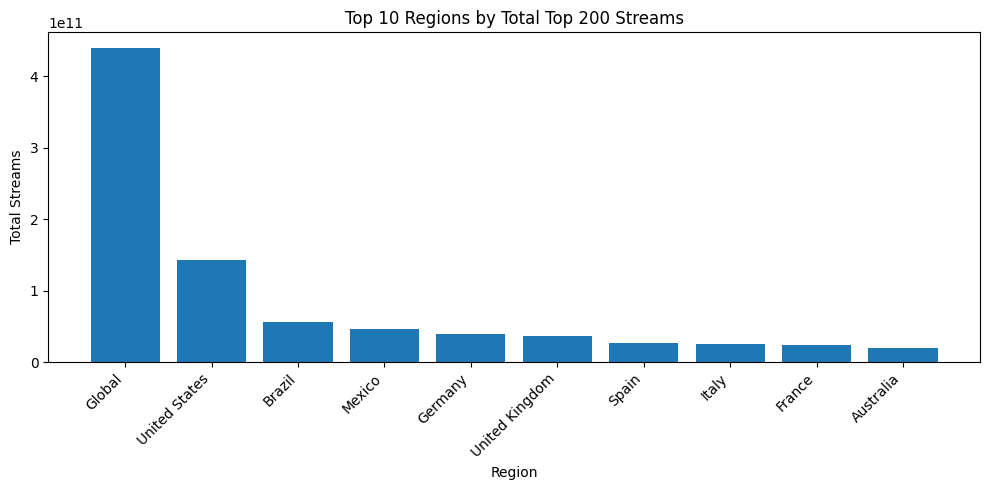

In [25]:
top10_regions = region_summary.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(top10_regions["region"], top10_regions["total_streams"])
plt.title("Top 10 Regions by Total Top 200 Streams")
plt.xlabel("Region")
plt.ylabel("Total Streams")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top10_regions_by_total_streams.png", dpi=300)
plt.show()